In [ ]:
%%html
<style>
    h1 {color:darkblue}
    h2 {color:purple}
    h3 {color:#0099ff}
    hr {
        border: 0;
        height: 3px;
        background: #333;
        background-image: linear-gradient(to right, limegreen, deepskyblue, limegreen);
    }
</style>

# Creating Agents with the OpenAI Agents SDK
---
# Image Generation and Editing with `ImageGenerationTool`
* OpenAI hosted tool 
* Agent decides whether to call the tool based on user prompt
* Edit an existing image by sending it as a base64 `data:` URL alongside the edit prompt
* If you want to perform multi-turn image updates, maintain conversation state as we did in earlier examples (e.g., `previous_response_id`)


---

---
## GPT Image 2.5: `gpt-image-2.5-flare` vs. `gpt-image-2.5-sunburst`
* Released September 8, 2026 — two API models replace the single `gpt-image-2`
* Both support the same parameters, endpoints and per-token pricing; they differ in speed and precision

| | **`gpt-image-2.5-flare`** | **`gpt-image-2.5-sunburst`** |
|:--|:--|:--|
| **OpenAI's positioning** | "fast, high-quality everyday image generation" | "most capable model for image generation and editing" |
| **Best for** | Interactive apps, batches, first drafts, live demos | Edits where the person/product must be preserved and only the requested element changes |
| **Latency** | Default model; about 50% faster than GPT Image 2 | Slower — trades generation time for control |
| **Reference-image fidelity** | Good | Strongest — carries earlier decisions through multiple edits |
| **Cost per image** | Same token rates; fewer tokens at a given quality means lower cost in practice | Same token rates ($5/M text in, $8/M image in, $30/M image out) |

* **Shared 2.5 features**
    * Five quality levels — `low`, `medium`, `high`, `xhigh`, `max` (plus `auto`); `max` on 2.5 ≈ `high` on GPT Image 2
    * Arbitrary sizes — `WIDTHxHEIGHT`, multiples of 16, aspect ratio 1:3 to 3:1, no edge over 3840 px (above 2560x1440 is experimental)
    * `background` — `transparent`, `opaque` (new) or `auto`; `output_format` — `png`, `jpeg`, `webp`; `output_compression` 0–100
    * Multi-turn editing via `previous_response_id`; `action` — `auto`, `generate` or `edit`
    * Up to four reference images per request; mask-based inpainting
    * `moderation` — `auto` or `low`
* **This notebook uses `flare`** so demos stay quick in class; switch `IMAGE_MODEL` to `sunburst` when edit precision matters more than speed
* https://developers.openai.com/api/docs/guides/image-generation

---


## Imports and Constants

In [1]:
import base64
from pathlib import Path

from IPython.display import Image, Markdown, display
import source.util as util
from agents import Agent, ImageGenerationTool, Runner, trace

IMAGE_MODEL = 'gpt-image-2.5-flare' # or 'gpt-image-2.5-sunburst' for editing precision
OUTPUT_DIR  = Path('resources') / 'outputs'

---
## `save_image` Utility Function
* Extracts base64-encoded result from first `image_generation_call` item in the completed run and writes it to disk


In [2]:
def save_image(result, path: Path) -> Path:
    """Write the first generated image from a completed run to disk."""

    # next() takes first image_generation_call result from the generator expression
    image_call = next(item.raw_item for item in result.new_items
        if getattr(item.raw_item, 'type', None) == 'image_generation_call')

    # create folder structure to save image if it does not exist
    path.parent.mkdir(parents=True, exist_ok=True) 

    # decode Base64 image data and write image bytes to path
    path.write_bytes(base64.b64decode(image_call.result))
    return path

---
## Image Agent

* Optional: Configure `ImageGenerationTool` 
    * We specified image model, size, and quality
* `size='auto'` lets the model choose orientation based on the prompt or source image
* The agent instructions tell the model when and how to use the tool


In [3]:
image_agent = Agent(
    name='ImageGenerationAssistant',
    model='gpt-5.6-terra',
    instructions="""You are an image-generation assistant.
        Use the image_generation tool when the user asks you to
        generate, restyle, refine, or transform an image. Produce one
        high-quality PNG image per request. Choose an appropriate 
        orientation based on the prompt or source image.""",
    tools=[
        ImageGenerationTool(
            tool_config={
                'type': 'image_generation',
                'model': IMAGE_MODEL,
                'size': 'auto',
                'quality': 'high'
            }
        )
    ]
)

---

## Demo 1: Generate an Image
* Agent knows from its instructions that it's an image-generation assistant
* Prompt only describes a scene without explicitly saying to create an image
* Agent's model uses its instructions and the prompt to determine that `ImageGenerationTool` is required

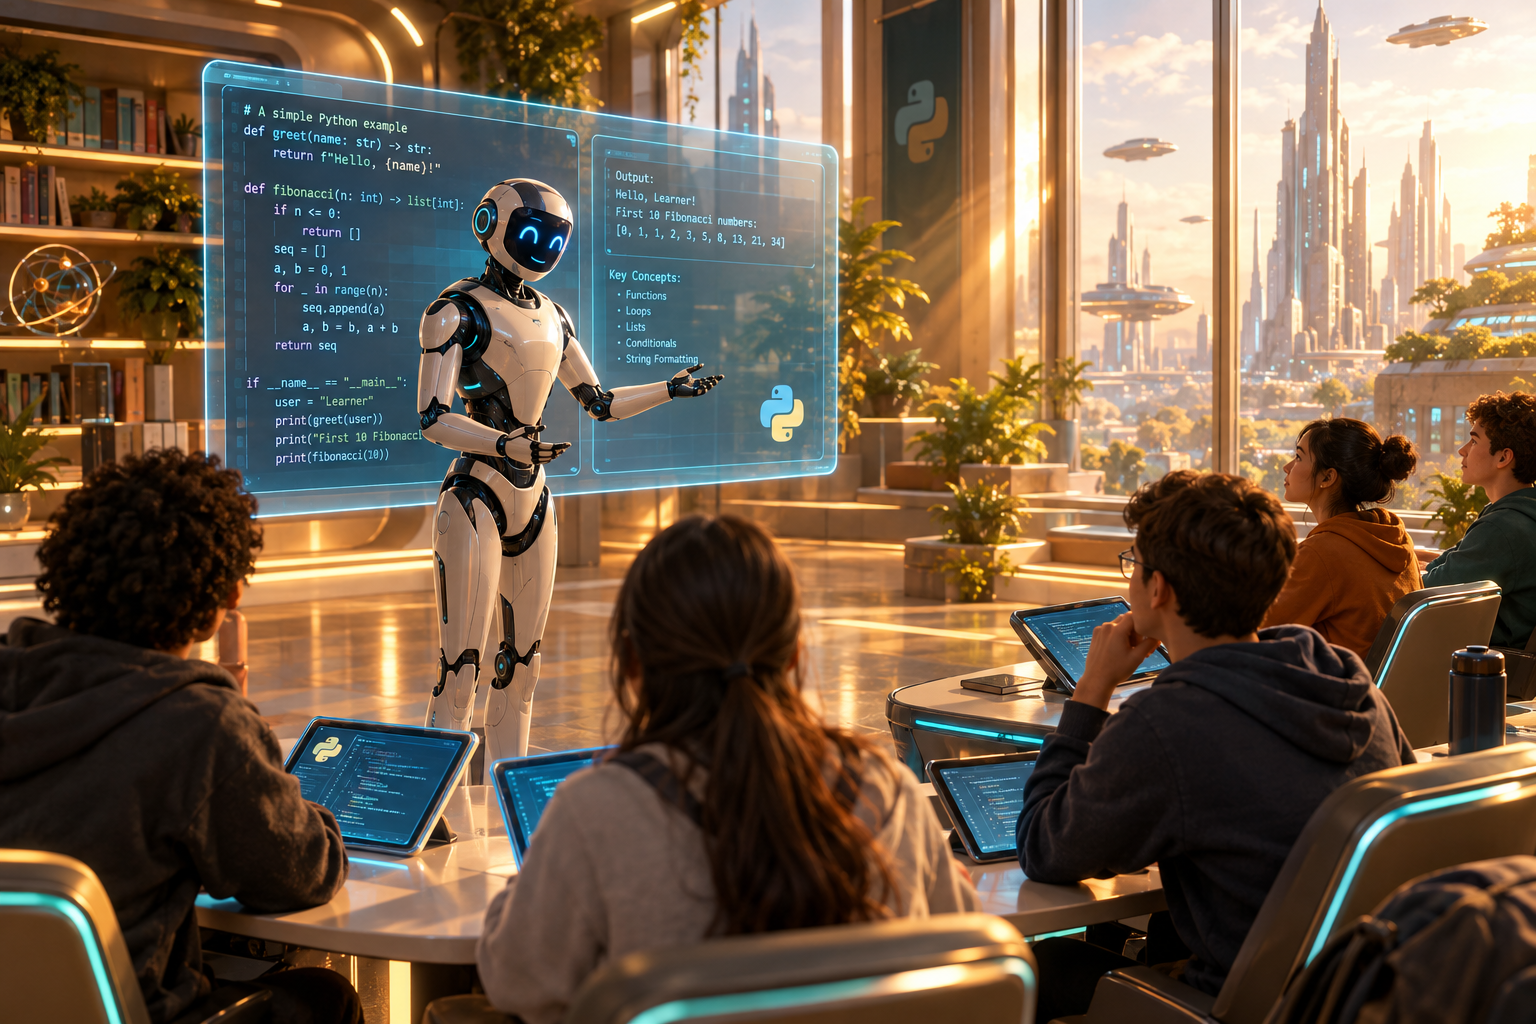

In [4]:
prompt = """A cinematic robot tutoring Python in a 
futuristic classroom, warm lighting."""

with trace('02-05-02-image-generate'):
    result1 = await Runner.run(image_agent, prompt)

path1 = save_image(result1, OUTPUT_DIR / 'image_demo1.png')
display(Markdown(result1.final_output))
display(Image(filename=str(path1), width=400))

---

## Demo 2: Image Edit for a Local Image Via a Prompt
* Represent local image as a base64 data URL
* Bundled base64 URL with the edit prompt in a multipart input
* `util.create_data_url` reads the image and encodes it
* Source image 
    > <img src="./resources/sunset.jpg" width=400 />

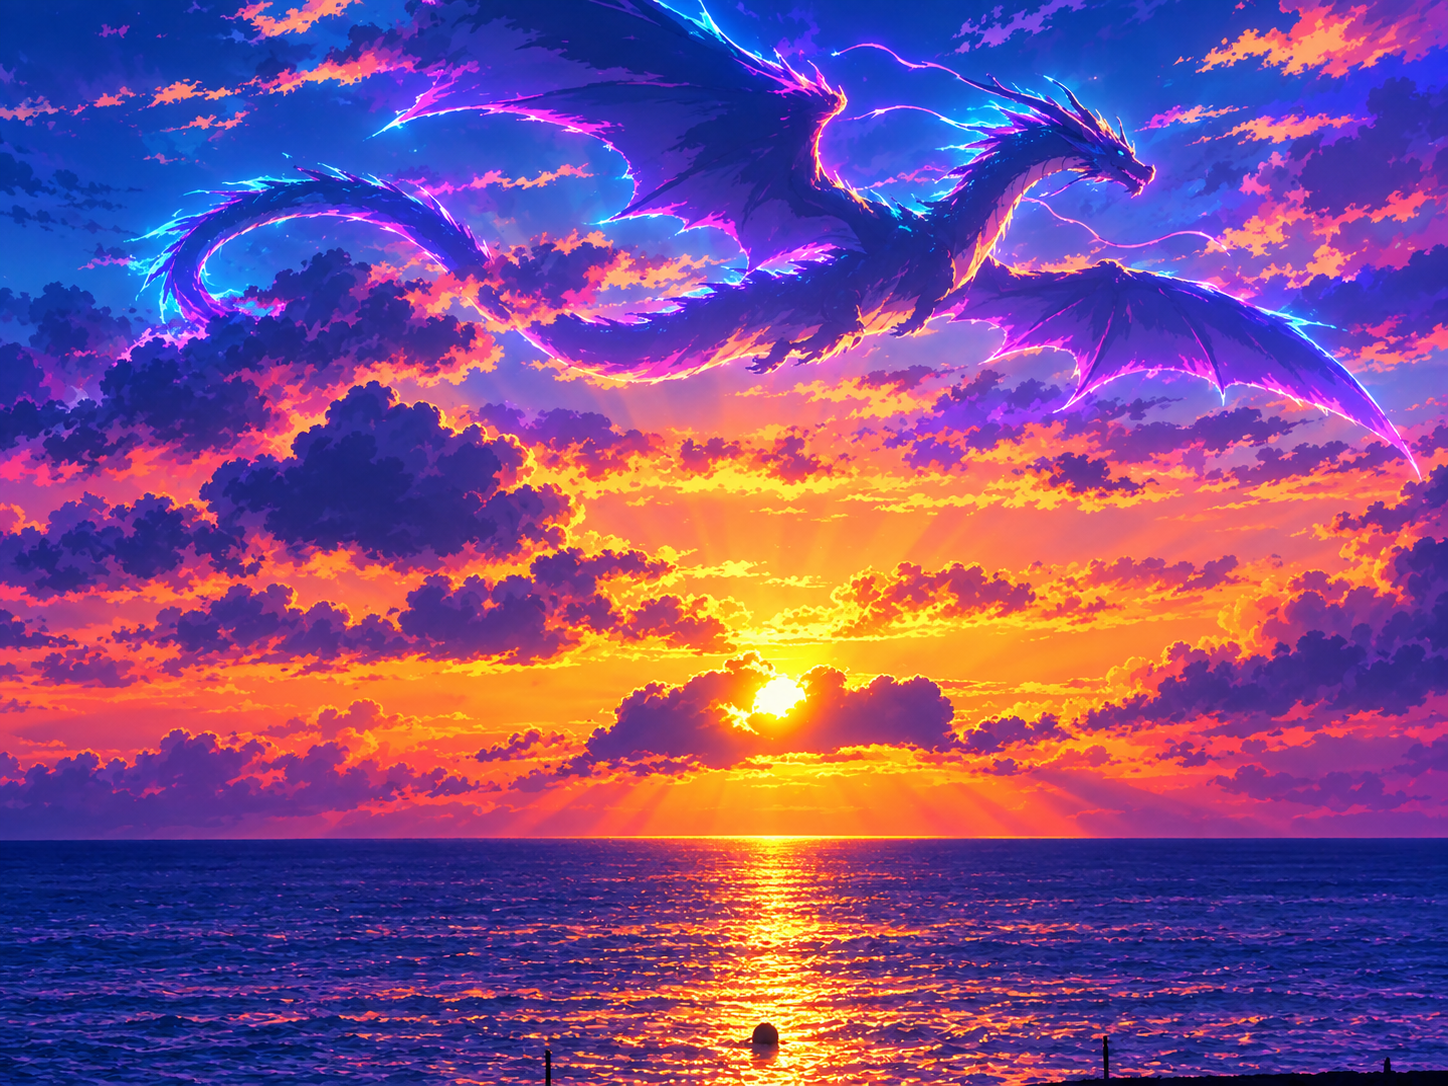

In [6]:
source_image = Path('resources') / 'sunset.jpg'
edit_prompt  = """Restyle this image as Japanese anime with neon colors
and add a flying dragon. Use the same aspect ratio."""

edit_input = [
    {
        'role': 'user',
        'content': [
            {
                'type': 'input_text',  
                'text': edit_prompt
            },
            {
                'type': 'input_image', 
                'image_url': util.create_data_url(source_image)
            }
        ]
    }
]

with trace('02-05-02-image-restyle-and-edit'):
    result2 = await Runner.run(image_agent, edit_input)

path2 = save_image(result2, OUTPUT_DIR / 'anime_sunset.png')
display(Markdown(result2.final_output))
display(Image(filename=str(path2), width=400))

---

## Defensive Coding for These Examples

* Validate style transfer input structure before sending — missing `input_image` silently produces a generation, not an edit
* Confirm local image paths exist before calling `create_data_url`
* Handle the case where no `image_generation_call` item is returned
    * For example, the request might violate OpenAI content policy
* Avoid overwriting files — generate unique filenames per run
* Catch API errors, rate limits, timeouts, and content-moderation failures
* Support explicit output formats, compression, and dimensions when downstream tools require them

---

## Documentation References

* [OpenAI Responses API image-generation tool](https://developers.openai.com/api/docs/guides/tools-image-generation)
* [OpenAI Agents SDK: Tools](https://openai.github.io/openai-agents-python/tools/)

---

© 2026 by Deitel & Associates, Inc. All Rights Reserved.